# **Brightness and contrast algorithm**
## Image Processing and Computer Vision


The simplest kinds of image processing transforms are point operators, where each output
pixel’s value depends on only the corresponding input pixel value (plus, potentially, some globally collected information or parameters).

Examples of such operators include **brightness and contrast** adjustments

In [28]:
import cv2
import matplotlib.pyplot as plt
import numpy as np


## Brightness and contrast adjustments (with function)

One approach is to use a multiplication and addition with a constant:

$$g(i,j) = \alpha * f(i,j) + \beta$$

Parameters:
- $\alpha$ (**gain**): alpha controls *contrast*. It'll modify how the levels spread. To lower the contrast, use 0 < $\alpha$ < 1. For higher contrast use $\alpha$ > 1.
- $\beta$ (**bias**): beta controls *brightness*

Functions:
- $g(i,j)$: output image
- $f(i,j)$: input image

where $i, j$ indicate that the pixel is located in the *i-th* row and *j-th* column.

Multiplicative gain (both global and spatially varying) is a linear operation, as it obeys
the superposition principle:

$$h(f_0 + f_1) = h(f_0) + h(f_1)$$

The following function implements the theory above:
- Input: an image and the parameters alpha and beta
- Converts the image to a larger data type (I had problem with computation of the formula)
- Compute the formula
- np.clip mantains the values between 0 and 255
- Convert the image to a smaller data type

In [29]:
def brightness_contrast(img, alpha = 1, beta = 0):
    input_img = img.astype(np.int16)
    return np.clip((alpha * input_img) + beta, 0, 255).astype(np.uint8)

### Grayscale image

In [40]:
IMG_PATH = "./img/tbbt.jpg"
alphas = [0.5, 1, 1.6]
betas = [-30, 0, 30]

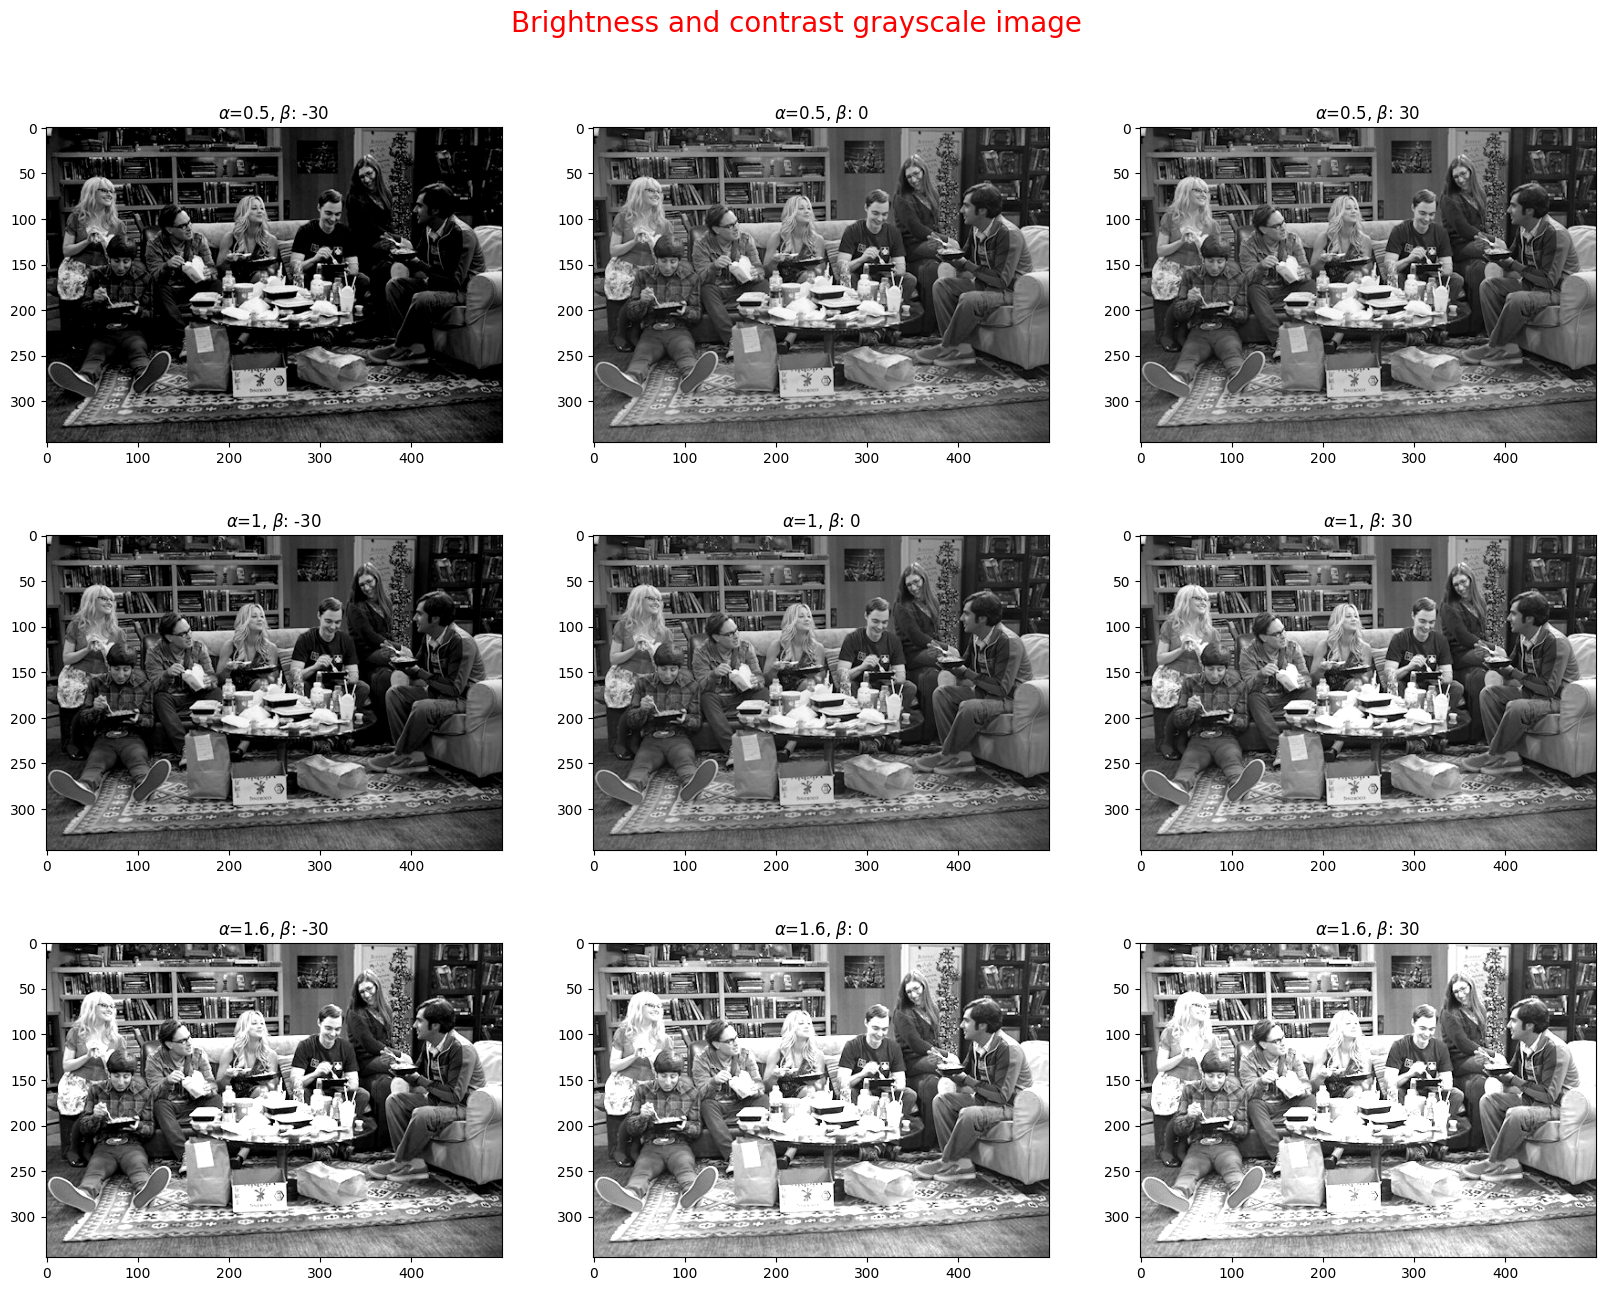

In [31]:
img = cv2.imread(IMG_PATH)
img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(20,15))
plt.suptitle("Brightness and contrast grayscale image", fontsize = 20, color = "red", y = 0.95)
i = 1

for alpha in alphas:
    for beta in betas:
        res = brightness_contrast(img, alpha, beta)

        plt.subplot(3,3, i)
        plt.imshow(res, cmap="gray")
        plt.title(f"$\\alpha$={alpha}, $\\beta$: {beta}")
        i+=1

plt.show()

I can analyze the images using the histogram for a better understanding of the function effect over the images

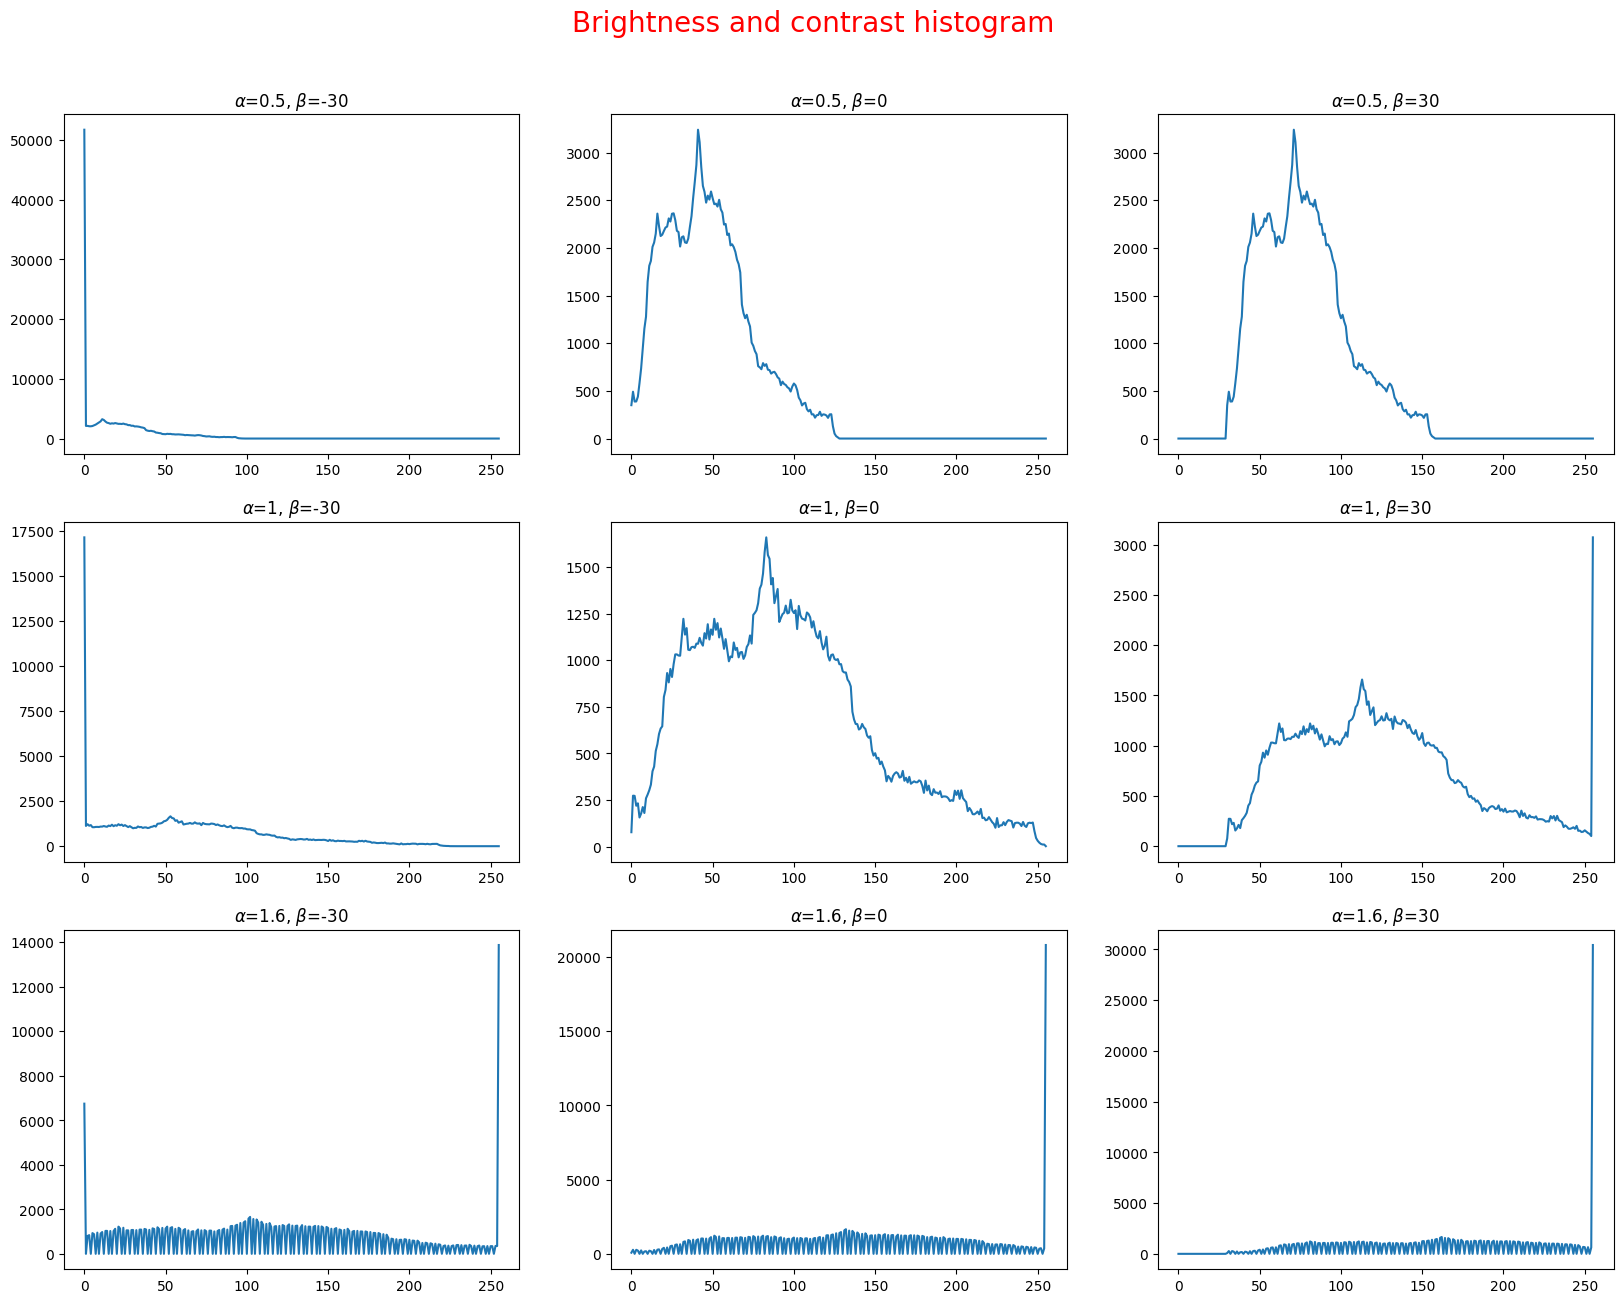

In [32]:
img = cv2.imread(IMG_PATH)
img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(20,15))
plt.suptitle("Brightness and contrast histogram", fontsize = 20, color = "red", y = 0.95)
i = 1

for alpha in alphas:
    for beta in betas: 
        res = brightness_contrast(img, alpha, beta)
        hist = cv2.calcHist([res], [0], None, [256], [0,256])

        plt.subplot(3,3, i)
        plt.plot(hist)
        plt.title(f"$\\alpha$={alpha}, $\\beta$={beta}")
        i+=1
        
plt.show()

### RGB image

In [33]:
IMG_PATH = "./img/tbbt.jpg"
alphas = [0.5, 1, 1.6]
betas = [-30, 0, 30]

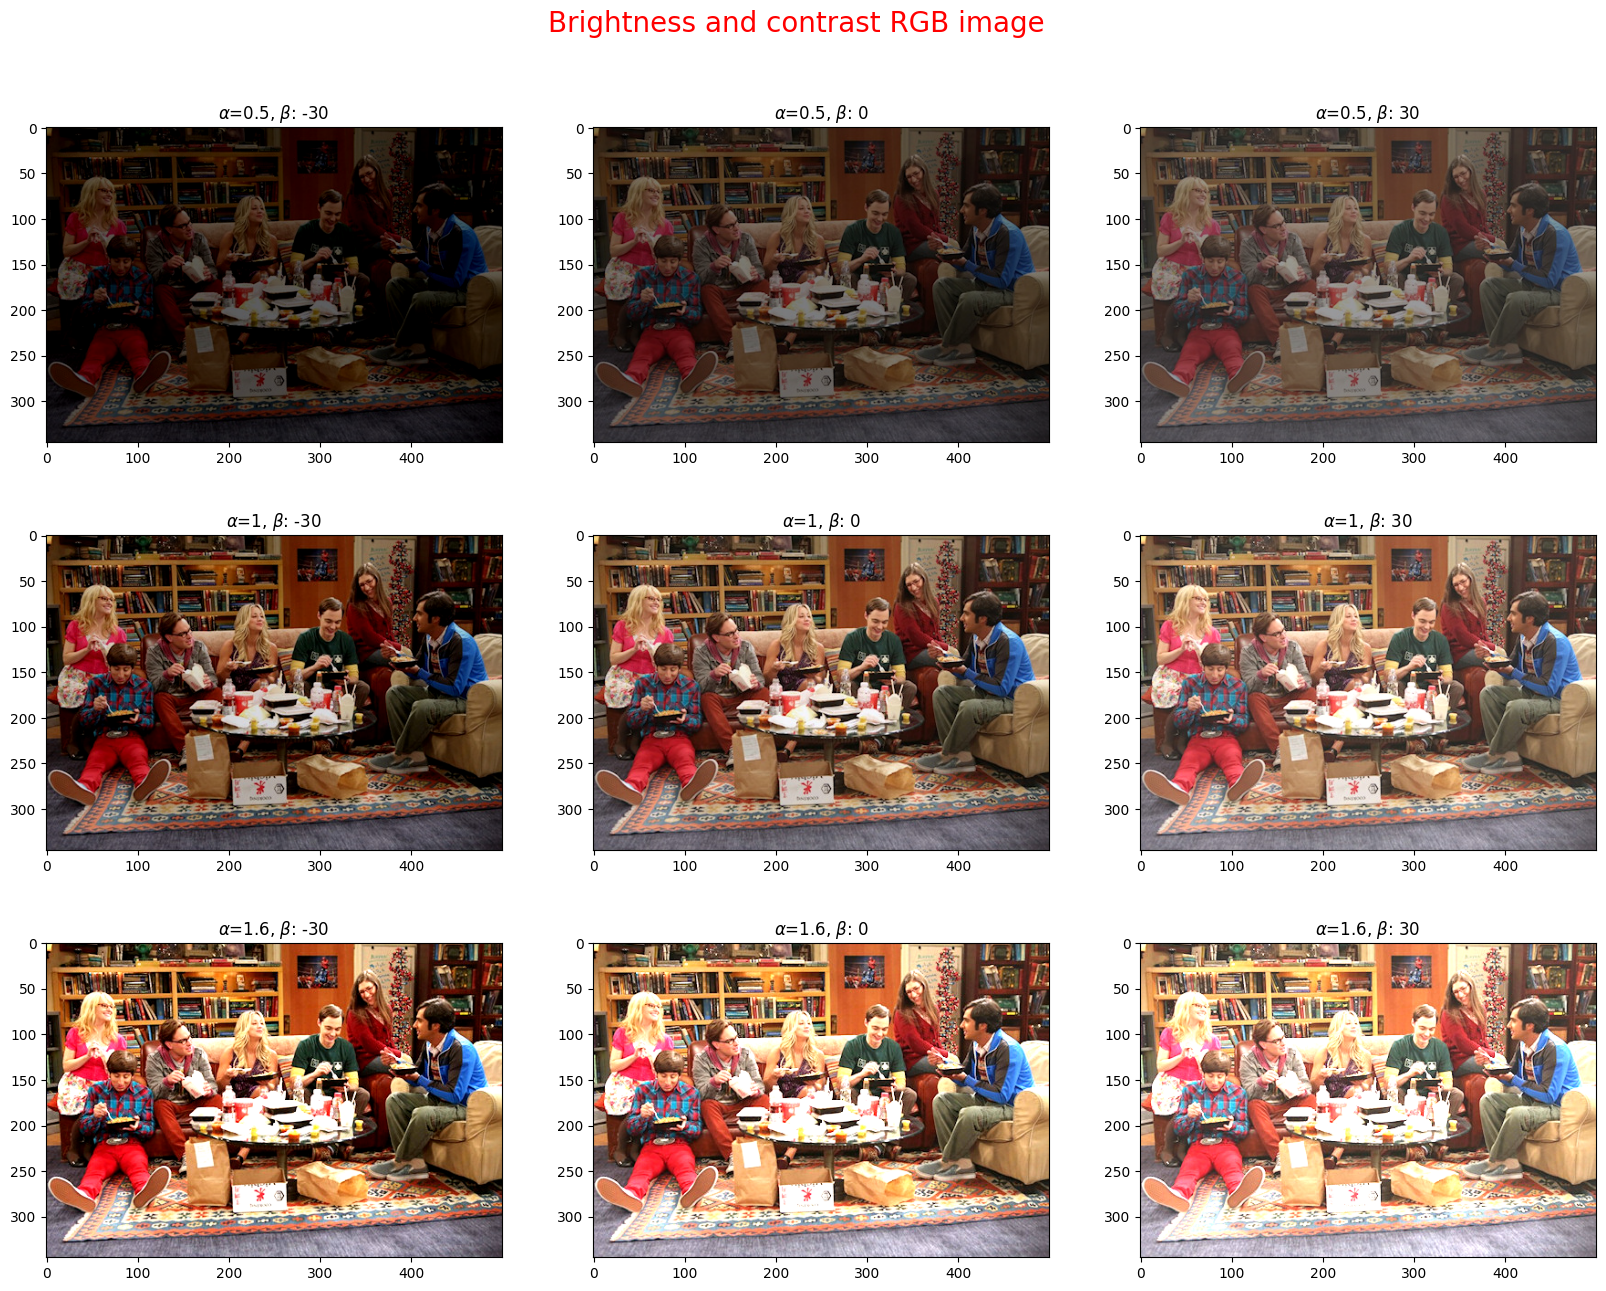

In [34]:
img = cv2.imread(IMG_PATH)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(20,15))
plt.suptitle(f"Brightness and contrast RGB image", fontsize = 20, color = "red", y = 0.95)
i = 1

for alpha in alphas:
    for beta in betas:
        res = brightness_contrast(img, alpha, beta)

        plt.subplot(3,3, i)
        plt.imshow(res, cmap="gray")
        plt.title(f"$\\alpha$={alpha}, $\\beta$: {beta}")
        i+=1

plt.show()

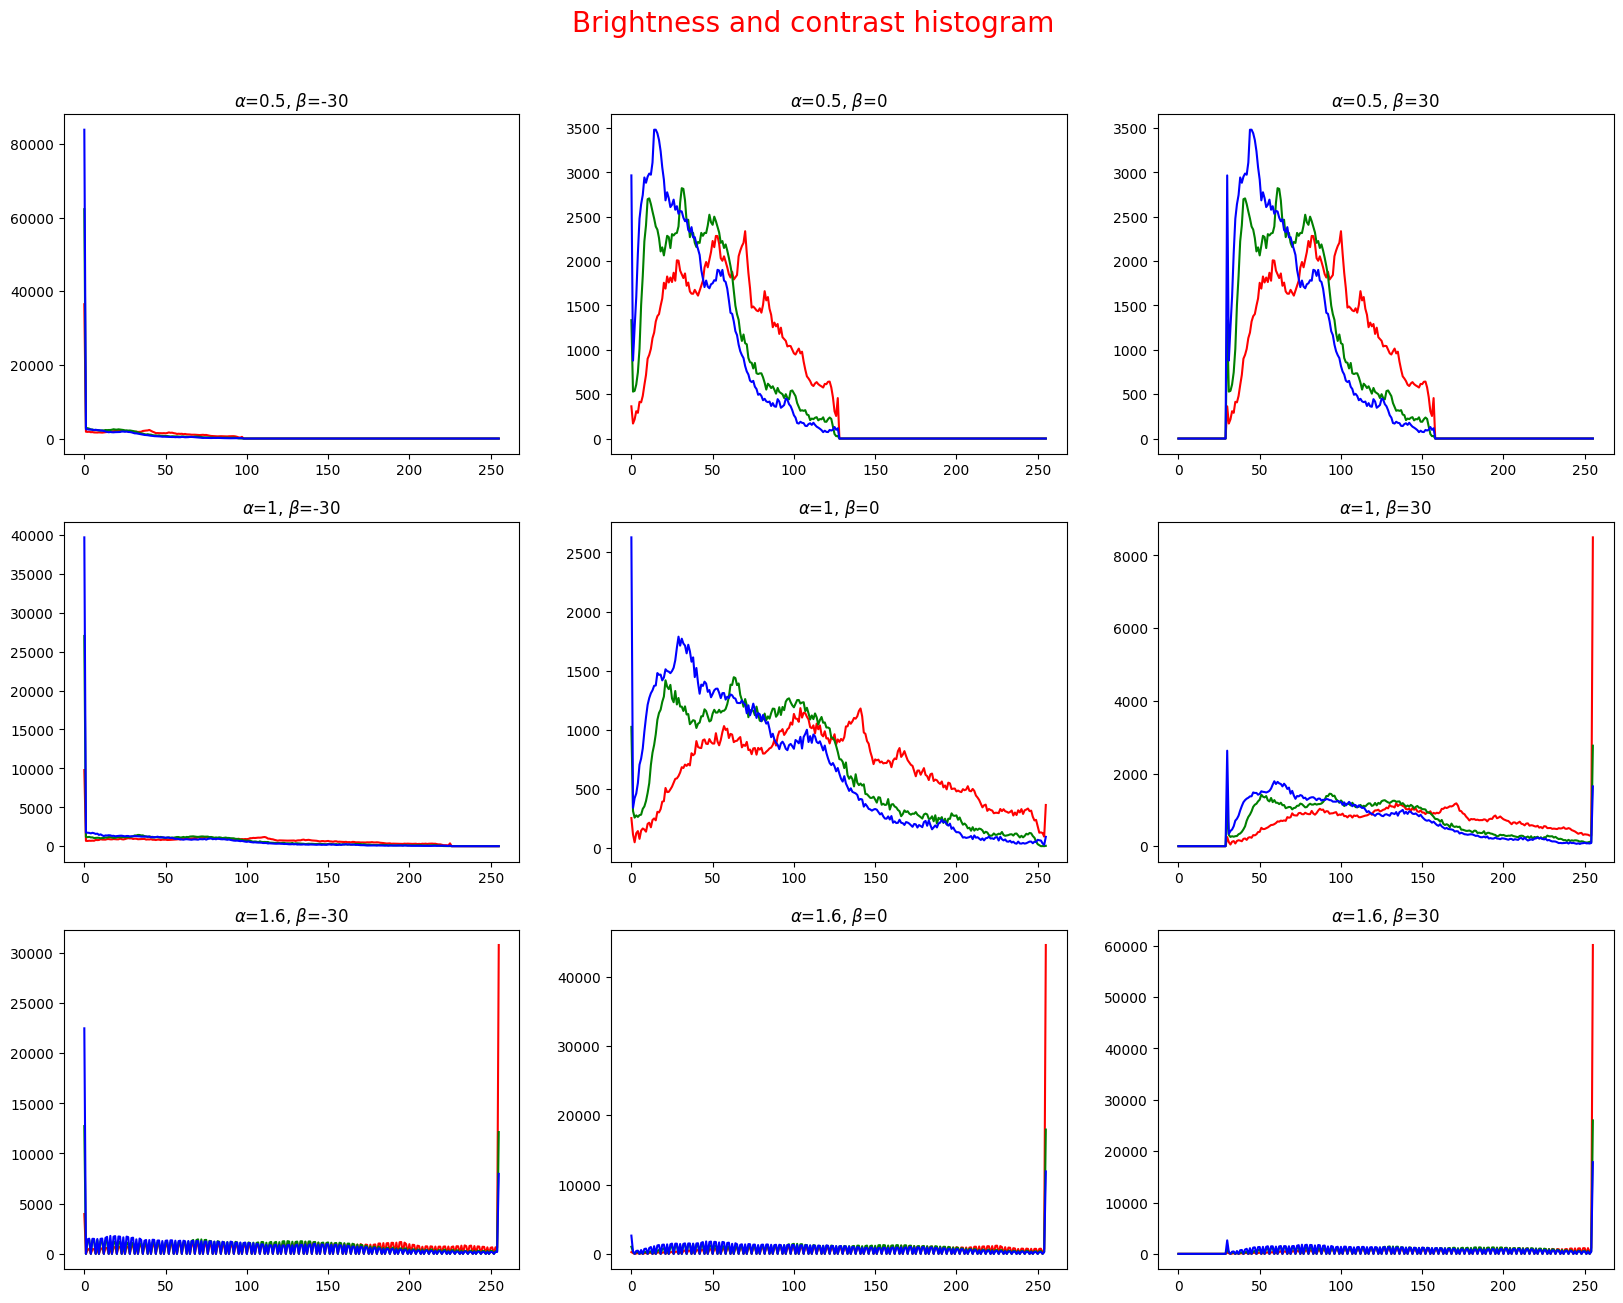

In [35]:
img = cv2.imread(IMG_PATH)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(20,15))
plt.suptitle("Brightness and contrast histogram", fontsize = 20, color = "red", y = 0.95)
i = 1

for alpha in alphas:
    for beta in betas: 
        res = brightness_contrast(img, alpha, beta)
        hist_r = cv2.calcHist([res], [0], None, [256], [0,256])
        hist_g = cv2.calcHist([res], [1], None, [256], [0,256])
        hist_b = cv2.calcHist([res], [2], None, [256], [0,256])

        plt.subplot(3,3, i)
        plt.plot(hist_r, color = "red")
        plt.plot(hist_g, color = "green")
        plt.plot(hist_b, color = "blue")
        plt.title(f"$\\alpha$={alpha}, $\\beta$={beta}")
        i+=1
        
plt.show()

### Conclusion

- When adding a constant bias, the histogram is **shifted to the right** as we have added a constant bias to all the pixels
- if $\alpha$ < 1, the color levels will be **compressed** and the result will be an image with less contrast
- The gain $\alpha$ can have as side-effect the saturation of some pixels, then we will **lose some details** in the original bright region

## Brightness and contrast adjustments (OpenCV function)

In OpenCV, to change the contrast and brightness of an image we could use **cv2.convertScaleAbs()**

On each element of the input array, the function convertScaleAbs **performs three operations sequentially**: scaling, taking an absolute value, conversion to an unsigned 8-bit type:

In [36]:
IMG_PATH = "./img/tbbt.jpg"
alphas = [0.5, 1, 1.6]
betas = [-30, 0, 30]

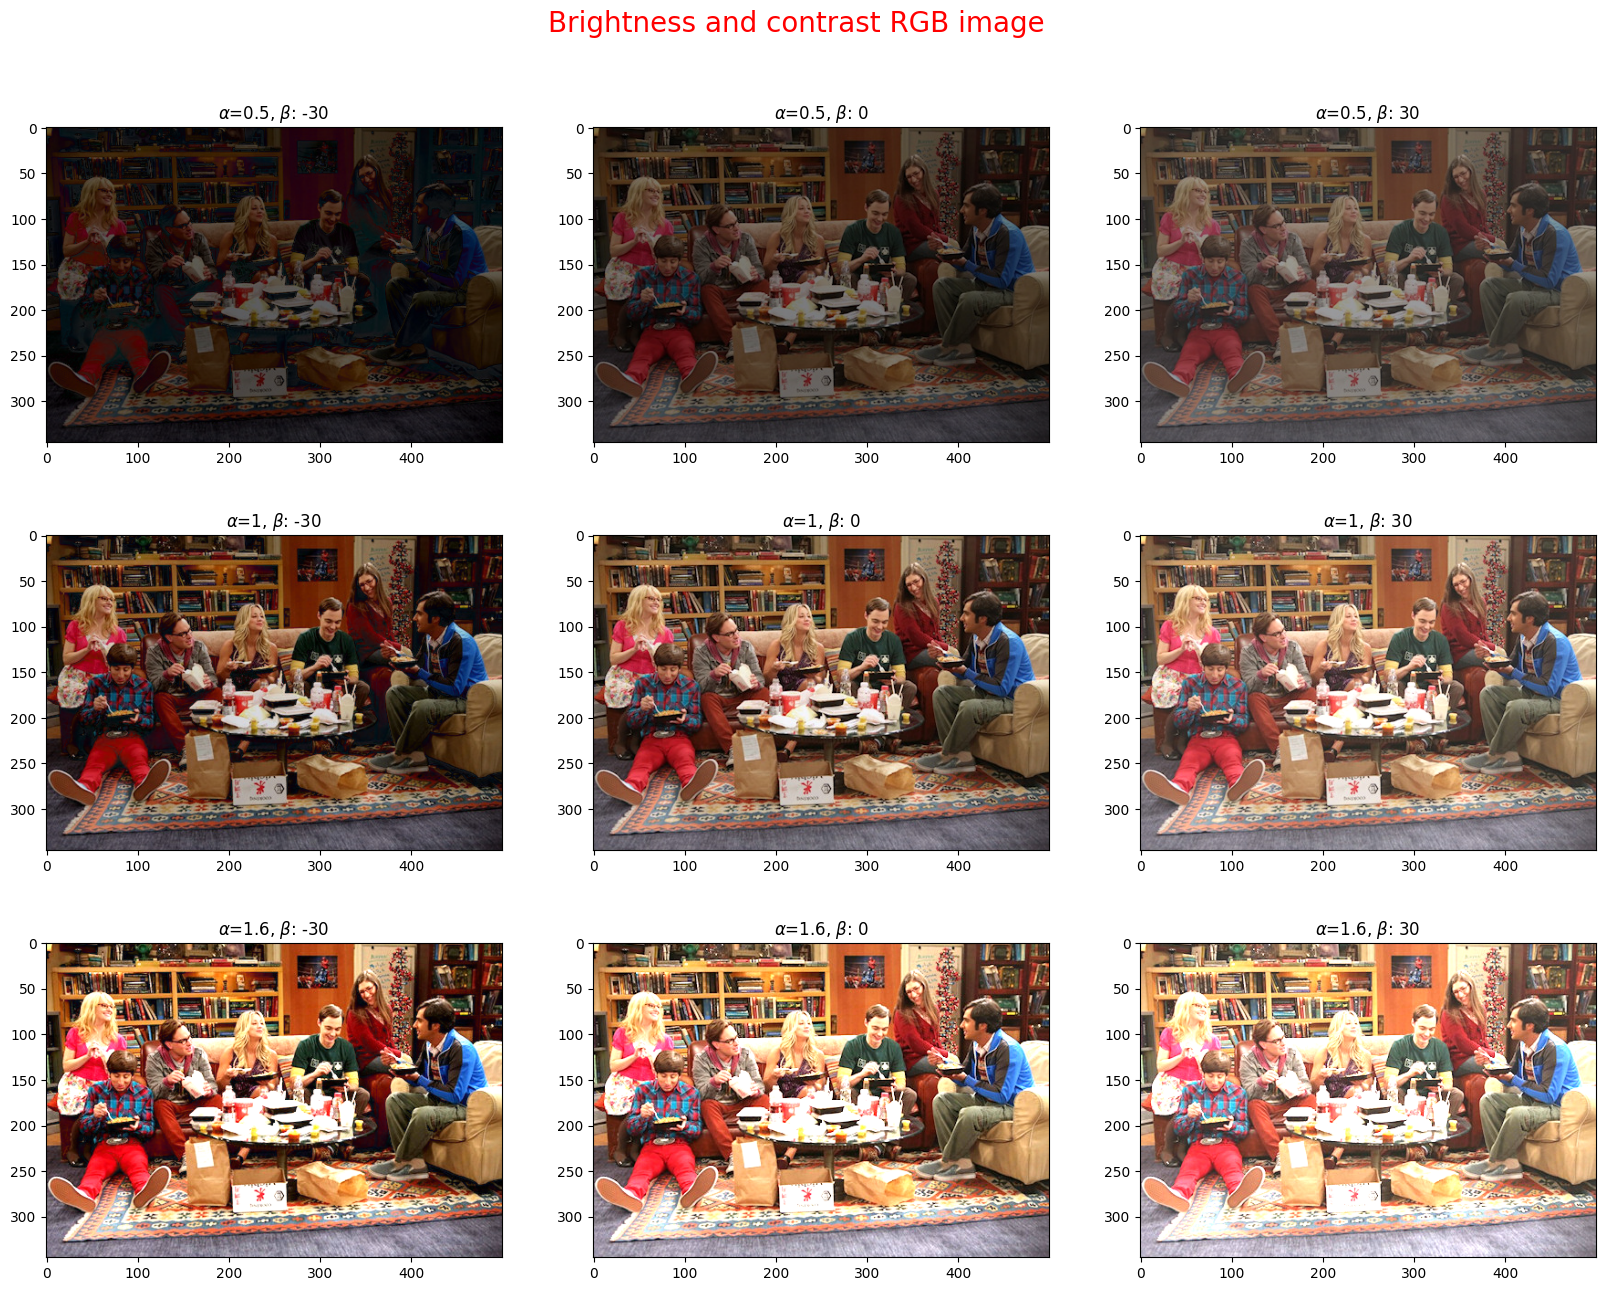

In [37]:
img = cv2.imread(IMG_PATH)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(20,15))
plt.suptitle(f"Brightness and contrast RGB image", fontsize = 20, color = "red", y = 0.95)
i = 1

for alpha in alphas:
    for beta in betas:
        res = cv2.convertScaleAbs(img, alpha=alpha, beta=beta)

        plt.subplot(3,3, i)
        plt.imshow(res, cmap="gray")
        plt.title(f"$\\alpha$={alpha}, $\\beta$: {beta}")
        i+=1

plt.show()

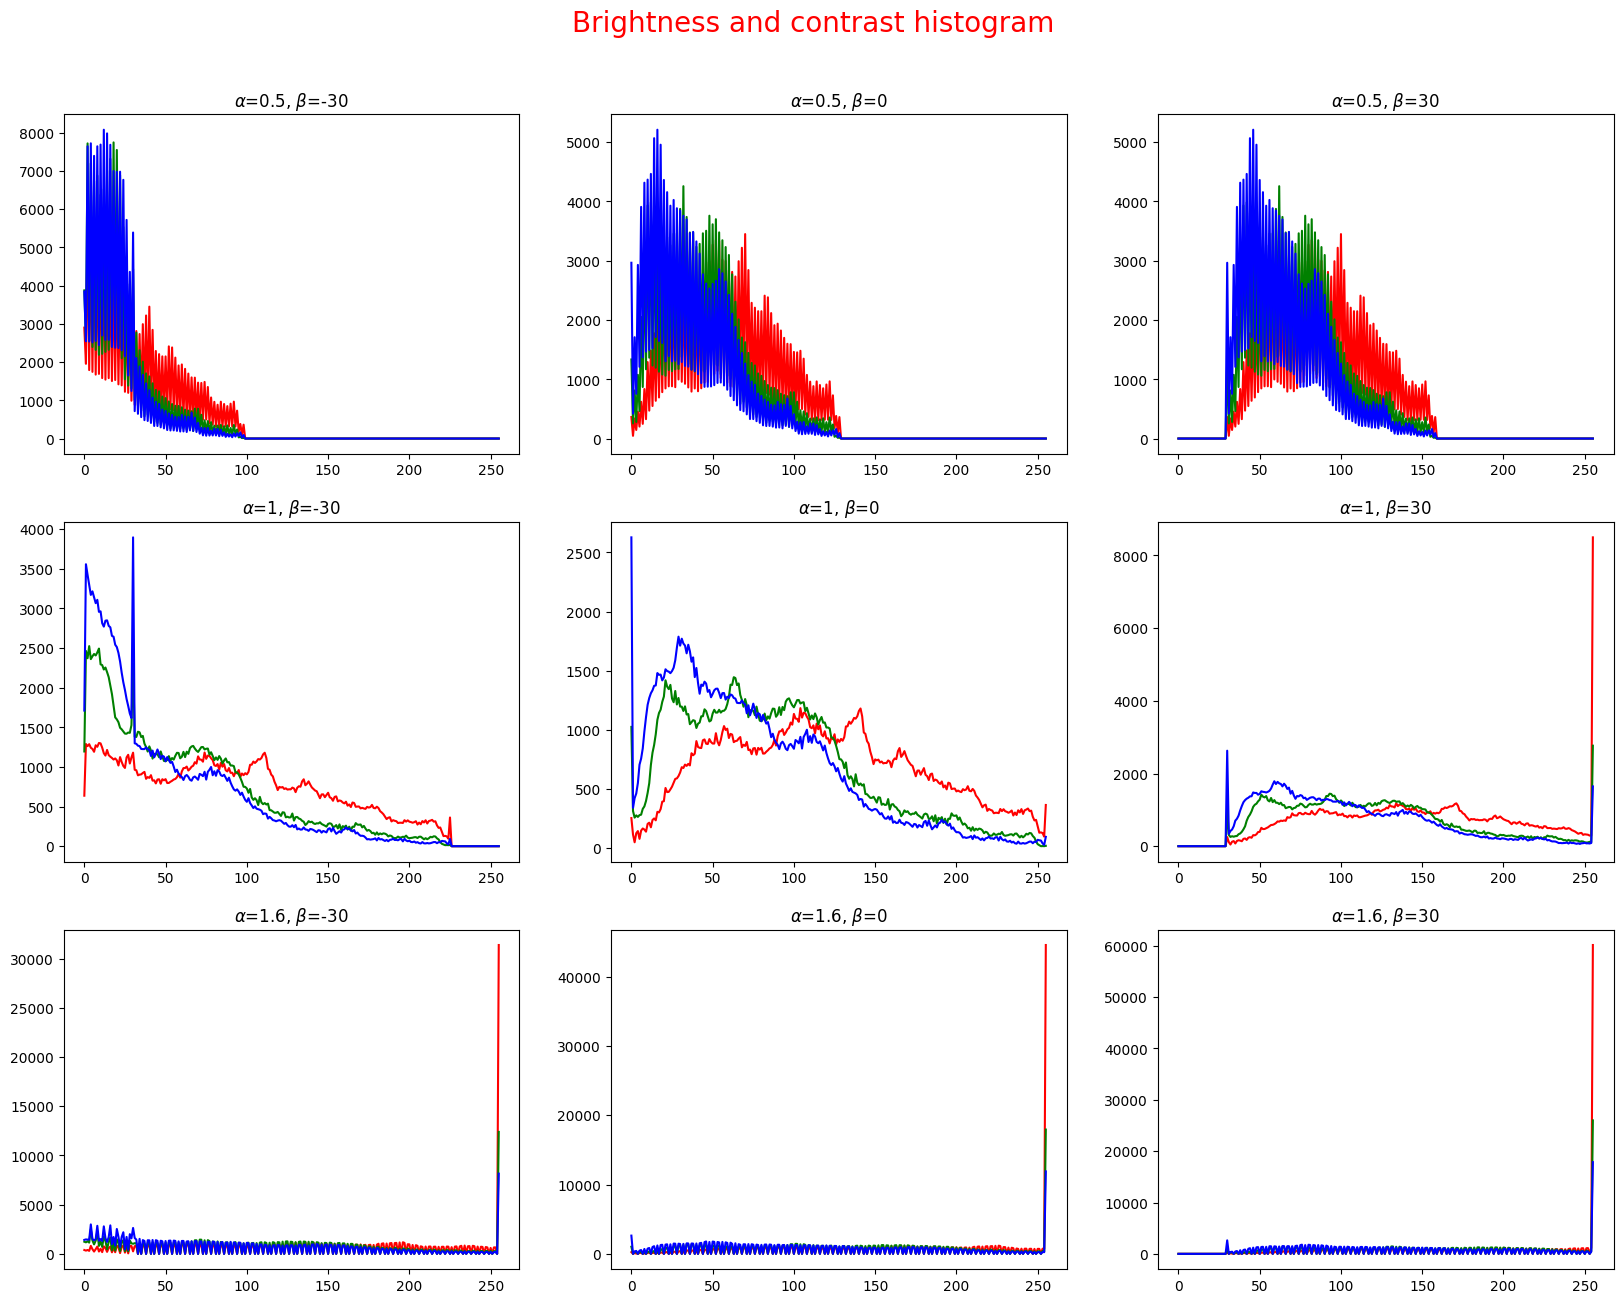

In [38]:
img = cv2.imread(IMG_PATH)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(20,15))
plt.suptitle("Brightness and contrast histogram", fontsize = 20, color = "red", y = 0.95)
i = 1

for alpha in alphas:
    for beta in betas: 
        res = cv2.convertScaleAbs(img, alpha=alpha, beta=beta)
        
        hist_r = cv2.calcHist([res], [0], None, [256], [0,256])
        hist_g = cv2.calcHist([res], [1], None, [256], [0,256])
        hist_b = cv2.calcHist([res], [2], None, [256], [0,256])

        plt.subplot(3,3, i)
        plt.plot(hist_r, color = "red")
        plt.plot(hist_g, color = "green")
        plt.plot(hist_b, color = "blue")
        plt.title(f"$\\alpha$={alpha}, $\\beta$={beta}")
        i+=1
        
plt.show()

## Gamma correction